# Heuristic Baseline

Now that we've done a little bit of EDA. What we need to do now is establish some sort of baseline for the heuristic we're going to choose and also define what metrics we're going to use to measure it. Because 

## Loading in the Data and Libraries

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss

In [76]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.head()


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [77]:
quali_df = pd.read_csv("../data/qualifying.csv", na_values="\\N")
quali_df.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [78]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [79]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [80]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [81]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## Finding the Heuristic Model

Let's start with the idea that, people who qualify close to the front of the grid are more likely to end up on the podium. So, what we'll do is:
* Look at the previous race data
* Find all the instances where that grid position ended up in a podium slot
* We'll then get a list of probabilities for each of the positions that we can apply as a model


In [82]:
grid_result_df = res_df[["resultId", "raceId", "grid", "position"]].copy()
grid_result_df

,resultId,raceId,grid,position
0,1,18,1.0,1.0
1,2,18,5.0,2.0
2,3,18,7.0,3.0
3,4,18,11.0,4.0
4,5,18,3.0,5.0
...,...,...,...,...
27299,27305,1171,21.0,18.0
27300,27306,1171,20.0,19.0
27301,27307,1171,17.0,20.0
27302,27308,1171,22.0,21.0


In [83]:
grid_result_df["podium"] = grid_result_df["position"] <= 3
grid_result_df

,resultId,raceId,grid,position,podium
0,1,18,1.0,1.0,True
1,2,18,5.0,2.0,True
2,3,18,7.0,3.0,True
3,4,18,11.0,4.0,False
4,5,18,3.0,5.0,False
...,...,...,...,...,...
27299,27305,1171,21.0,18.0,False
27300,27306,1171,20.0,19.0,False
27301,27307,1171,17.0,20.0,False
27302,27308,1171,22.0,21.0,False


In [84]:
pd.DataFrame(grid_result_df.groupby("grid")["podium"].mean()).reset_index()

,grid,podium
0,0.0,0.000000
1,1.0,0.639415
2,2.0,0.562989
3,3.0,0.465398
4,4.0,0.341969
5,5.0,0.247841
6,6.0,0.182450
7,7.0,0.127476
8,8.0,0.096970
9,9.0,0.081174


We can see here that we get up to 34 positions, this is because at the moment we're training on the *full* set of data, which we probably don't want to. We'll restrict it back down to anything post 1990 up to the end of 2024 to keep it consistent

In [85]:
recent_grid_result_df = grid_result_df.copy()

recent_grid_result_df = pd.merge(
    left=recent_grid_result_df,
    right=race_df[["raceId", "year"]],
    on="raceId"
)

recent_grid_result_df = recent_grid_result_df[(recent_grid_result_df["year"] >= 1990) & (recent_grid_result_df["year"] < 2024)]
recent_grid_result_df

,resultId,raceId,grid,position,podium,year
0,1,18,1.0,1.0,True,2008
1,2,18,5.0,2.0,True,2008
2,3,18,7.0,3.0,True,2008
3,4,18,11.0,4.0,False,2008
4,5,18,3.0,5.0,False,2008
...,...,...,...,...,...,...
26275,26281,1120,20.0,16.0,False,2023
26276,26282,1120,19.0,17.0,False,2023
26277,26283,1120,16.0,18.0,False,2023
26278,26284,1120,18.0,19.0,False,2023


In [86]:
pd.DataFrame(recent_grid_result_df.groupby("grid")["podium"].mean()).reset_index()

,grid,podium
0,0.0,0.000000
1,1.0,0.743922
2,2.0,0.622764
3,3.0,0.512156
4,4.0,0.332253
5,5.0,0.210697
6,6.0,0.170178
7,7.0,0.100486
8,8.0,0.072934
9,9.0,0.051864


F12 didn't settle on 20-22 grids until about 2010, these don't really provide much utility because the signal is tiny in them anyway. Also we have position 0 as pit late starts which we can probably ignore as well

In [87]:
recent_grid_result_df = recent_grid_result_df[
    (recent_grid_result_df["grid"] > 0) & 
    (recent_grid_result_df["grid"] <= 22)
]

grid_podium_probabilities_df = pd.DataFrame(recent_grid_result_df.groupby("grid")["podium"].mean()).reset_index()
grid_podium_probabilities_df

,grid,podium
0,1.0,0.743922
1,2.0,0.622764
2,3.0,0.512156
3,4.0,0.332253
4,5.0,0.210697
5,6.0,0.170178
6,7.0,0.100486
7,8.0,0.072934
8,9.0,0.051864
9,10.0,0.045528


## Choosing a Metric

How do we *measure* how accurate our model is? We've got a couple of different options here:
* F1 score is a decent option, as it balances precision and recall so we can see if we're too liberal or conservative with our labelling. The problem though is that to calculate an F1 score we need a threshold and we have to *choose* that threshold which limits our visibility. Because there are only 3 podium slots and 22 drivers now, our positive class is heavily imbalanced which makes it easy to game.
* AUC/ROC is a little better for this reason, we can see the whole curve and how choosing particular probabilities thresholds affects the results.
* Brier score might actually be the best because we're working with probabilities, if we had a particular probability, atleast with AUC/ROC we could be massively off in our predicted probabilities and still correct, because Brier score is the mean of the squared differences of the actual vs predicted probabilities it gives us a better picture of not only if we are correct or not, but *how* correct our probability range is. The squaring affect also means that we can heavily punish the model being overconfident on incorrect answers, and also penalisizing underconfidence as well.

In summary, I think that we can and should use a combination of:
* Brier score (Primary)
* AUC/ROC (Secondary)

The Brier score will tell us "How well are your probabilities calcuclated?" and the AUC tells us if the model is ranking drivers correctly. This gives us a nice complete picture of how well our model is doing.


So, now for the big question. How well does our heuristic model do? We'll use 2025 as our test set:

## Evaluating the Heuristic Model

### AUC/ROC


In [88]:
race_result_df = pd.merge(
    left=res_df[["raceId", "resultId", "grid", "position"]],
    right=race_df[["raceId", "year"]],
    on="raceId"
)

race_result_2025_df = race_result_df[(race_result_df["year"] >= 2025) & (race_result_df["year"] <= 2025)].copy()
race_result_2025_df

,raceId,resultId,grid,position,year
26759,1145,26765,1.0,1.0,2025
26760,1145,26766,3.0,2.0,2025
26761,1145,26767,4.0,3.0,2025
26762,1145,26768,16.0,4.0,2025
26763,1145,26769,6.0,5.0,2025
...,...,...,...,...,...
27233,1168,27239,17.0,16.0,2025
27234,1168,27240,9.0,17.0,2025
27235,1168,27241,13.0,18.0,2025
27236,1168,27242,19.0,19.0,2025


In [89]:
race_result_2025_df["podiumFinish"] = np.where(race_result_2025_df["position"] <= 3, 1, 0) 
race_result_2025_df 

,raceId,resultId,grid,position,year,podiumFinish
26759,1145,26765,1.0,1.0,2025,1
26760,1145,26766,3.0,2.0,2025,1
26761,1145,26767,4.0,3.0,2025,1
26762,1145,26768,16.0,4.0,2025,0
26763,1145,26769,6.0,5.0,2025,0
...,...,...,...,...,...,...
27233,1168,27239,17.0,16.0,2025,0
27234,1168,27240,9.0,17.0,2025,0
27235,1168,27241,13.0,18.0,2025,0
27236,1168,27242,19.0,19.0,2025,0


In [90]:
race_result_2025_df = pd.merge(
    left=race_result_2025_df,
    right=grid_podium_probabilities_df,
    on="grid"
).rename(columns={"podium": "podiumProbability"})

race_result_2025_df

,raceId,resultId,grid,position,year,podiumFinish,podiumProbability
0,1145,26765,1.0,1.0,2025,1,0.743922
1,1145,26766,3.0,2.0,2025,1,0.512156
2,1145,26767,4.0,3.0,2025,1,0.332253
3,1145,26768,16.0,4.0,2025,0,0.008130
4,1145,26769,6.0,5.0,2025,0,0.170178
...,...,...,...,...,...,...,...
454,1168,27239,17.0,16.0,2025,0,0.008091
455,1168,27240,9.0,17.0,2025,0,0.051864
456,1168,27241,13.0,18.0,2025,0,0.021104
457,1168,27242,19.0,19.0,2025,0,0.003306


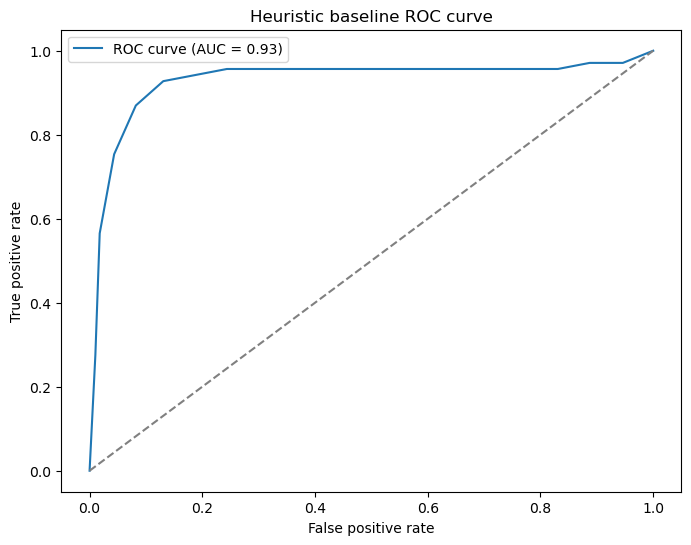

In [91]:
# Compute the ROC curve and the AUC score.
fpr, tpr, thresholds = roc_curve(race_result_2025_df["podiumFinish"], race_result_2025_df["podiumProbability"])
auc_score = roc_auc_score(race_result_2025_df["podiumFinish"], race_result_2025_df["podiumProbability"])
auc_value = auc(fpr, tpr)

# Plot the ROC curve and show the AUC score.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Heuristic baseline ROC curve')
plt.legend()
plt.show()


### Brier Score

Now we move on to calculating the Brier score, we want values close to 0 as 0 would be perfectly accurate probabilities, 1 would be perfectly innacurate. We end up with 0.06 (to 2 d.p) which is remarkably good already.


In [92]:
brier_score_loss(race_result_2025_df["podiumFinish"], race_result_2025_df["podiumProbability"])

0.059599599672017896

## The Problem

One of the problems that we have however, is that using the qualifying position for the race is kind of cheating. It's halfway through the race weekend and a lot of other variables get baked into those qualifying positions which make them so strong!

Let's instead choose something that we know outside of the race weekend entirely. Let's go for, the last 5 races and if the driver achived a podium, and then we can apply these percentages forward for the driver.

In [93]:
race_results_by_year_df = pd.merge(
    left=res_df[["resultId", "raceId", "driverId", "grid", "position"]],
    right=race_df[["raceId", "year", "round"]],
    on="raceId"
).sort_values(["year", "round"])

race_results_by_year_df = pd.merge(
    left=race_results_by_year_df,
    right=drivers_df[["driverId", "forename", "surname"]],
    on="driverId"
)

race_results_by_year_df["driverName"] = race_results_by_year_df["forename"] + " " +  race_results_by_year_df["surname"]
race_results_by_year_df = race_results_by_year_df.drop(columns=["forename", "surname"])

race_results_by_year_df

,resultId,raceId,driverId,grid,position,year,round,driverName
0,20025,833,642,1.0,1.0,1950,1,Nino Farina
1,20026,833,786,2.0,2.0,1950,1,Luigi Fagioli
2,20027,833,686,4.0,3.0,1950,1,Reg Parnell
3,20028,833,704,6.0,4.0,1950,1,Yves Cabantous
4,20029,833,627,9.0,5.0,1950,1,Louis Rosier
...,...,...,...,...,...,...,...,...
27299,27305,1171,4,21.0,18.0,2026,3,Fernando Alonso
27300,27306,1171,822,20.0,19.0,2026,3,Valtteri Bottas
27301,27307,1171,848,17.0,20.0,2026,3,Alexander Albon
27302,27308,1171,840,22.0,21.0,2026,3,Lance Stroll


In [94]:
race_results_by_year_df = race_results_by_year_df[
    (race_results_by_year_df["year"] >= 1990) & 
    (race_results_by_year_df["year"] <= 2025)
].copy()

race_results_by_year_df

,resultId,raceId,driverId,grid,position,year,round,driverName
12430,7012,321,102,5.0,1.0,1990,1,Ayrton Senna
12431,7013,321,55,4.0,2.0,1990,1,Jean Alesi
12432,7014,321,123,9.0,3.0,1990,1,Thierry Boutsen
12433,7015,321,137,6.0,4.0,1990,1,Nelson Piquet
12434,7016,321,131,10.0,5.0,1990,1,Stefano Modena
...,...,...,...,...,...,...,...,...
27233,27239,1168,848,17.0,16.0,2025,24,Alexander Albon
27234,27240,1168,865,9.0,17.0,2025,24,Isack Hadjar
27235,27241,1168,859,13.0,18.0,2025,24,Liam Lawson
27236,27242,1168,842,19.0,19.0,2025,24,Pierre Gasly


In [95]:
# Binary podium column
race_results_by_year_df["podium"] = race_results_by_year_df["position"] <= 3

# Rolling podium rate per driver (last 5 races, excluding current)
race_results_by_year_df["driver_podium_rate_5"] = (
    race_results_by_year_df.groupby("driverId")["podium"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

race_results_by_year_df.tail()

,resultId,raceId,driverId,grid,position,year,round,driverName,podium,driver_podium_rate_5
27233,27239,1168,848,17.0,16.0,2025,24,Alexander Albon,False,0.0
27234,27240,1168,865,9.0,17.0,2025,24,Isack Hadjar,False,0.0
27235,27241,1168,859,13.0,18.0,2025,24,Liam Lawson,False,0.0
27236,27242,1168,842,19.0,19.0,2025,24,Pierre Gasly,False,0.0
27237,27243,1168,861,20.0,20.0,2025,24,Franco Colapinto,False,0.0


In [99]:
driver_current_form = (
    race_results_by_year_df.groupby("driverId")[["driver_podium_rate_5", "driverName"]]
    .last()
    .reset_index()
)

driver_current_form

,driverId,driver_podium_rate_5,driverName
0,1,0.0,Lewis Hamilton
1,2,0.0,Nick Heidfeld
2,3,1.0,Nico Rosberg
3,4,0.0,Fernando Alonso
4,5,0.0,Heikki Kovalainen
...,...,...,...
207,861,0.0,Franco Colapinto
208,862,0.0,Jack Doohan
209,863,0.4,Andrea Kimi Antonelli
210,864,0.0,Gabriel Bortoleto


NameError: name 'min_24_races_driver_position_df' is not defined

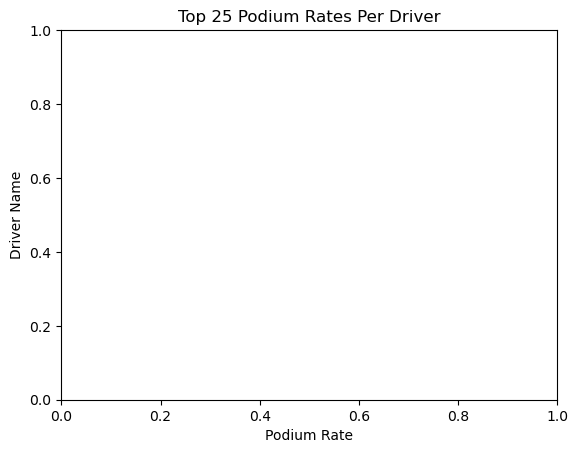

In [97]:
plt.title("Top 25 Podium Rates Per Driver")
plt.xlabel("Podium Rate")
plt.ylabel("Driver Name")

sns.barplot(min_24_races_driver_position_df[:25], x="podium_rate", y="name")

two things we need to do, filter the drivers by the ones in the current season. Also, we need to fill with 0 for DNF so we don't end up with NaN on the result

## Summary

So, without any ML applied whatsoever yet - we have a somewhat decent model with:
* An AUC of 0.93
* A Brier Score of 0.06 (to 2 d.p)

Which is going to be hard to beat! But atleast now we are armed with metrics going in.